# OASIS INFOBYTE SIP – Task 1
## EDA on Retail Sales Data

**Track:** Data Analytics  
**Level:** Level 1  
**Task:** Task 1 – EDA on Retail Sales Data

### Objective
Perform Exploratory Data Analysis (EDA) on retail sales data to identify sales trends, customer behaviour patterns, product performance and actionable business insights.

**Tools:** Python, pandas, matplotlib, seaborn, Jupyter Notebook


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [ ]:
df = pd.read_csv("data/retail_sales.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-07-09,CUST001,Female,59,Clothing,1,300,300
1,2,2023-09-26,CUST002,Male,20,Electronics,1,50,50
2,3,2023-09-27,CUST003,Female,36,Clothing,3,30,90
3,4,2023-08-29,CUST004,Female,39,Clothing,3,300,900
4,5,2023-05-30,CUST005,Male,55,Electronics,4,25,100


### Observation
The dataset contains retail transactions with transaction details, customer demographics, product categories, quantity, unit price and total amount.

## 3. Initial Inspection

In [ ]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.info()


Shape: (1000, 9)

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   

### Observation
The dataset has 1,000 transaction records and 9 columns. The data types are suitable for analysis after converting the Date column to datetime. Missing values and duplicate records are checked before analysis.

## 4. Data Preparation

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

numeric_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

def age_group(age):
    if age <= 24:
        return "18-24"
    elif age <= 34:
        return "25-34"
    elif age <= 44:
        return "35-44"
    elif age <= 54:
        return "45-54"
    else:
        return "55-64"

df["Age Group"] = df["Age"].apply(age_group)
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Age Group
0,1,2023-07-09,CUST001,Female,59,Clothing,1,300,300,2023-07,2023Q3,55-64
1,2,2023-09-26,CUST002,Male,20,Electronics,1,50,50,2023-09,2023Q3,18-24
2,3,2023-09-27,CUST003,Female,36,Clothing,3,30,90,2023-09,2023Q3,35-44
3,4,2023-08-29,CUST004,Female,39,Clothing,3,300,900,2023-08,2023Q3,35-44
4,5,2023-05-30,CUST005,Male,55,Electronics,4,25,100,2023-05,2023Q2,55-64


## 5. Descriptive Statistics

In [ ]:
stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
})
stats


,Mean,Median,Mode,Standard Deviation
Age,41.182,41.0,36.0,13.558123
Quantity,2.504,3.0,3.0,1.115001
Price per Unit,156.685,50.0,50.0,177.309544
Total Amount,379.300,120.0,100.0,502.152235


### Observation
Descriptive statistics summarize the centre and spread of the numerical variables. They help identify typical transaction values, customer age, quantity purchased and price variation.

## 6. Monthly Sales Trend

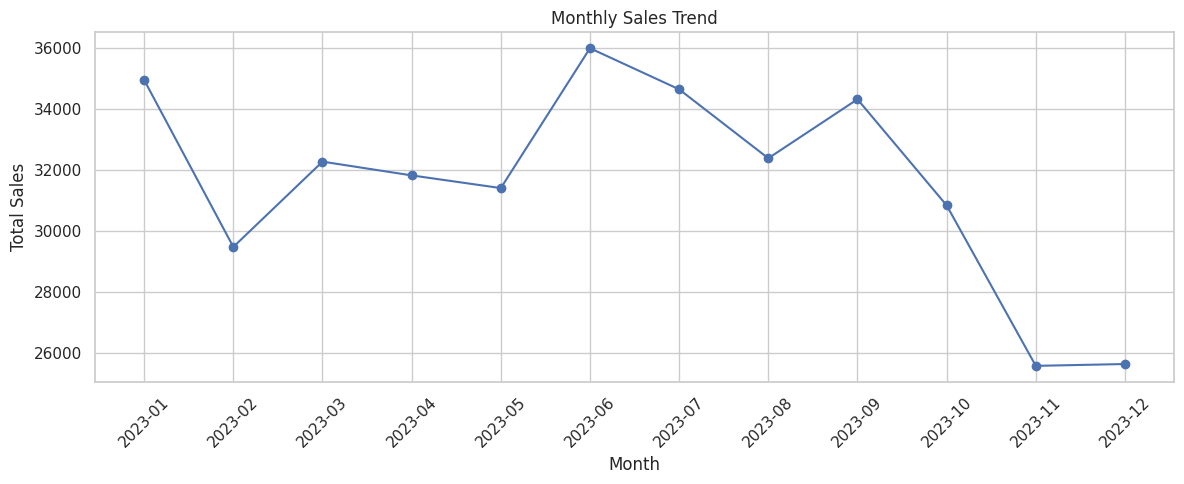

In [ ]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Observation
The monthly line chart shows how sales change across the year. Peaks can be used for campaign planning, inventory preparation and promotional timing.

## 7. Quarterly Sales Trend

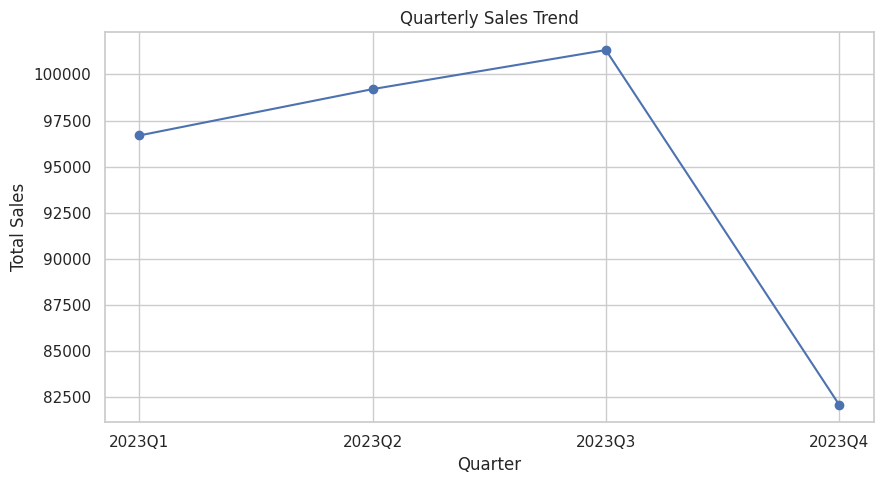

In [ ]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(9,5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


### Observation
Quarterly aggregation provides a higher-level view of business performance and makes it easier to compare broader periods.

## 8. Customer Demographics – Age Group

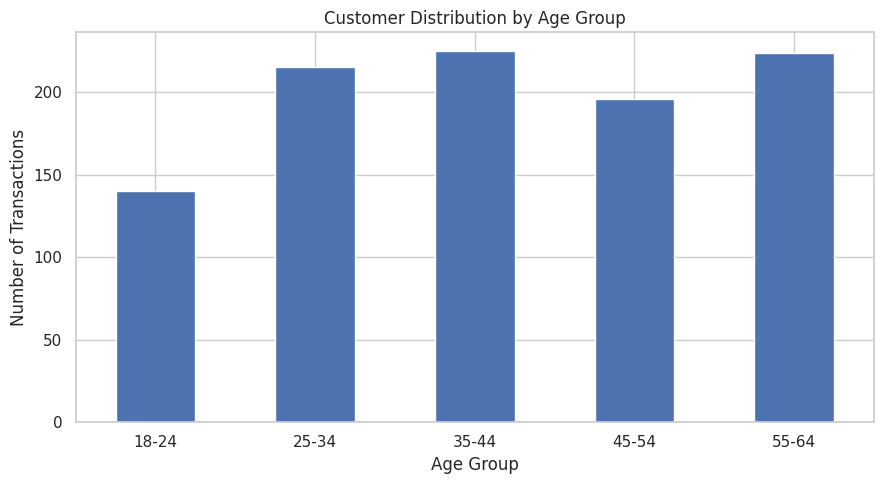

In [ ]:
age_counts = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(9,5))
age_counts.plot(kind="bar")
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Observation
The age-group chart identifies which customer age ranges contribute most of the transaction activity. These groups can be considered when designing targeted promotions.

## 9. Customer Demographics – Gender

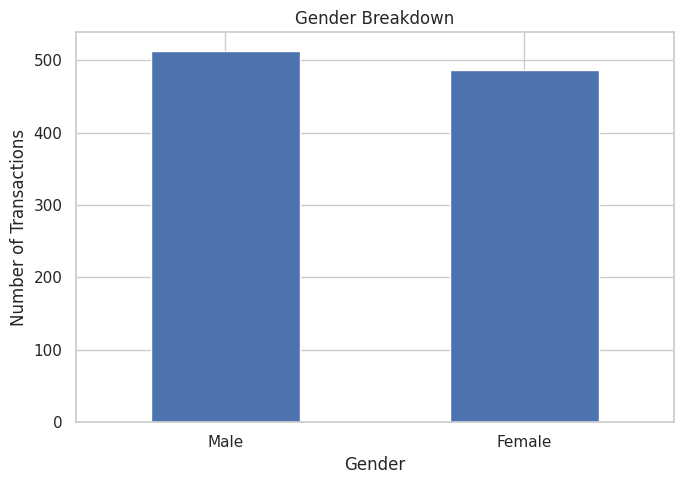

In [ ]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7,5))
gender_counts.plot(kind="bar")
plt.title("Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Observation
The gender breakdown helps understand the composition of the customer base and supports demographic-level marketing analysis.

## 10. Top 10 Best-Selling Products
### Note
The provided task dataset contains **Product Category** rather than a separate product-name field. Therefore, the closest supported product-level analysis is the top 10 product-category/price combinations by units sold.

In [ ]:
product_proxy = (
    df.groupby(["Product Category", "Price per Unit"])["Quantity"]
      .sum()
      .reset_index()
      .sort_values("Quantity", ascending=False)
      .head(10)
)

product_proxy


,Product Category,Price per Unit,Quantity
2,Beauty,50,226
11,Electronics,30,226
12,Electronics,50,222
0,Beauty,25,200
5,Clothing,25,196
1,Beauty,30,174
7,Clothing,50,168
3,Beauty,300,160
9,Clothing,500,151
10,Electronics,25,150


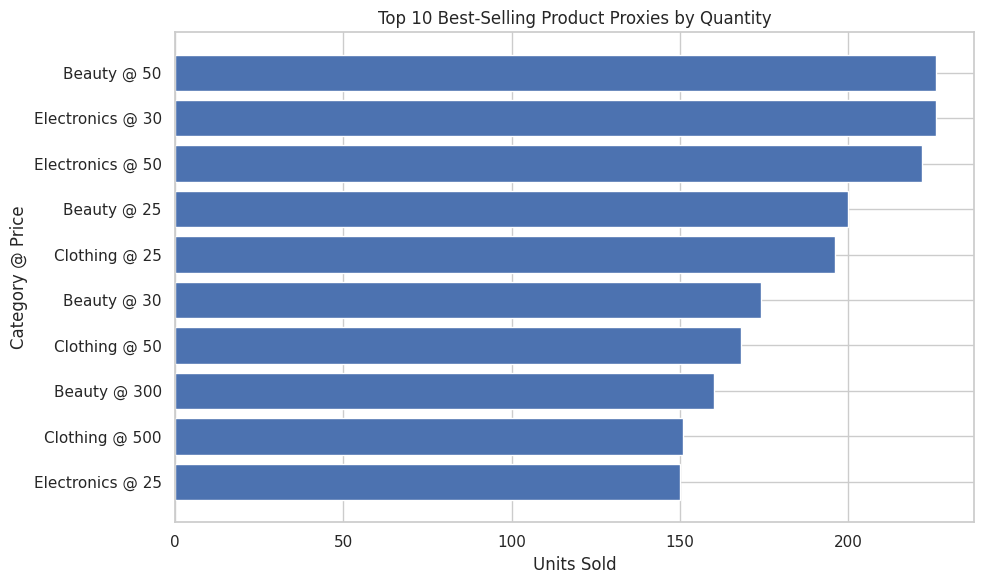

In [ ]:
labels = product_proxy["Product Category"] + " @ " + product_proxy["Price per Unit"].astype(str)

plt.figure(figsize=(10,6))
plt.barh(labels[::-1], product_proxy["Quantity"].values[::-1])
plt.title("Top 10 Best-Selling Product Proxies by Quantity")
plt.xlabel("Units Sold")
plt.ylabel("Category @ Price")
plt.tight_layout()
plt.show()


### Observation
Because no Product Name column exists, this chart uses product category plus price point as a transparent proxy. This avoids inventing product names that are not present in the source data.

## 11. Revenue by Product Category

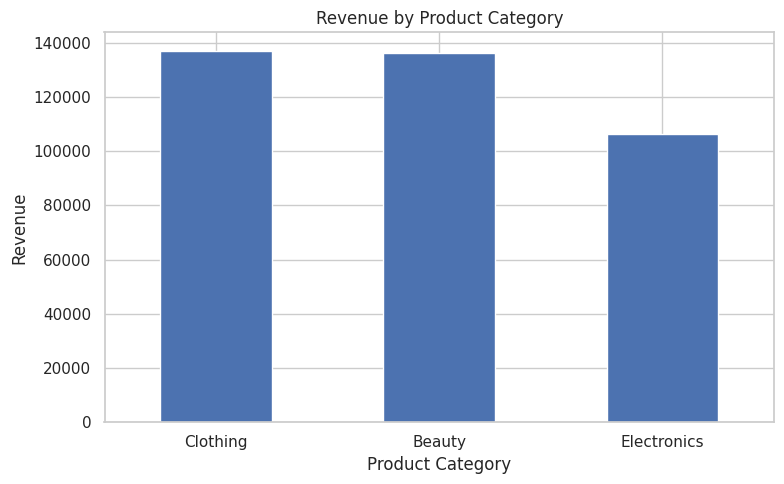

In [ ]:
category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Observation
Comparing category revenue helps management identify which broad product areas contribute most to total sales and where inventory or promotion decisions may have the largest effect.

## 12. Correlation Heatmap

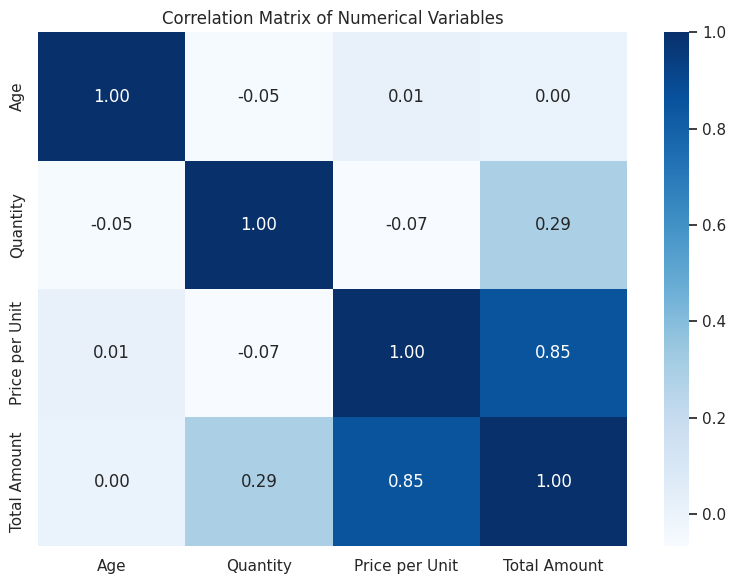

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


### Observation
The heatmap highlights relationships among age, quantity, unit price and total amount. A strong relationship between quantity and total amount is expected because transaction amount is calculated from quantity and unit price.

## 13. Additional Visualization – Average Transaction Value by Age Group

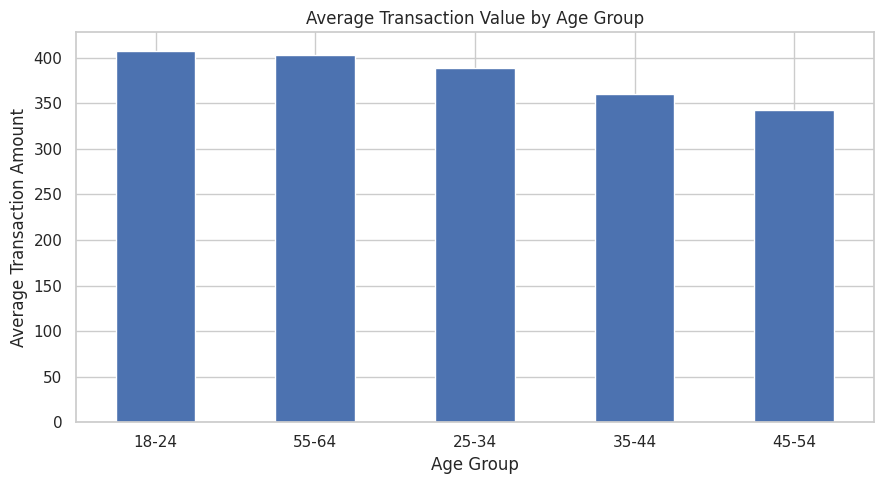

In [ ]:
avg_age_sales = df.groupby("Age Group")["Total Amount"].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
avg_age_sales.plot(kind="bar")
plt.title("Average Transaction Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Observation
Average transaction value can reveal a non-obvious difference between customer groups: the group with the most transactions is not necessarily the group with the highest average spend per transaction.

## 14. Key Business Insights

In [ ]:
summary = {
    "Total Revenue": df["Total Amount"].sum(),
    "Total Units Sold": df["Quantity"].sum(),
    "Average Transaction Value": df["Total Amount"].mean(),
    "Top Revenue Category": category_revenue.idxmax(),
    "Top Revenue Category Sales": category_revenue.max(),
    "Largest Age Group by Transactions": age_counts.idxmax(),
    "Largest Gender Group by Transactions": gender_counts.idxmax(),
}
pd.Series(summary)


Total Revenue                             379300
Total Units Sold                            2504
Average Transaction Value                  379.3
Top Revenue Category                    Clothing
Top Revenue Category Sales                136950
Largest Age Group by Transactions          35-44
Largest Gender Group by Transactions        Male
dtype: object

## 15. Conclusion and Actionable Recommendations

1. **Plan inventory and promotions around stronger sales periods:** use the monthly and quarterly trend charts to prepare stock and campaigns ahead of higher-demand periods.
2. **Target high-value customer groups:** use age-group and average transaction analysis to create focused offers for groups with higher spending potential.
3. **Prioritize strong product categories:** use category revenue results to guide inventory availability, merchandising and promotional budgets.
4. **Use quantity-price relationships for bundle offers:** where customers purchase multiple units, test bundles or volume promotions to increase basket size.
5. **Track category performance continuously:** repeat this EDA on new monthly data so changes in demand can be detected early.


## 16. Project Completion Checklist

- [x] Dataset loaded and inspected
- [x] Shape, data types and null values checked
- [x] Mean, median, mode and standard deviation calculated
- [x] Monthly sales trend
- [x] Quarterly sales trend
- [x] Age-group distribution
- [x] Gender breakdown
- [x] Top 10 supported product proxy analysis
- [x] Revenue by product category
- [x] Correlation heatmap
- [x] Additional visualization
- [x] Markdown observations after charts
- [x] Actionable business recommendations
